# Predictive Lead Ranking — historical decision support

## Business question
Which 100 historical bank-marketing records would a model prioritize under a fixed contact capacity?
This is a retrospective holdout demonstration, not a live contact list or an estimate of the effect of calling.
A lead is a dataset record; `source_row_id` is its zero-based source row, not a verified customer identifier.

In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import importlib.metadata
import json
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             PrecisionRecallDisplay, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "data/bank-full.csv").is_file() and (p / "app/app.py").is_file())
SEED = 42
TOP_K = 100  # fixed before selection or holdout evaluation
warnings.filterwarnings("error", category=ConvergenceWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Dataset and data quality
The unchanged `bank-full.csv` contains 45,211 records from the UCI Bank Marketing collection.
See [data documentation](../data/README.md) for verified provenance, definitions and exclusions.
`unknown` is retained as an explicit category, not silently treated as a known value. There are no nulls
or exact duplicate full rows in this file. Numeric extremes are retained: their magnitudes alone do not
prove recording errors. No population-level filtering or imputation is performed.

In [2]:
data_path = ROOT / "data/bank-full.csv"
df = pd.read_csv(data_path, sep=";")
df.index.name = "source_row_id"
assert df.shape == (45211, 17)
assert set(df["y"].unique()) == {"yes", "no"}
assert not df.isna().any().any()
assert not df.duplicated().any()
source_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()
quality = {
    "rows": len(df), "columns": df.shape[1],
    "null_values": int(df.isna().sum().sum()),
    "duplicate_full_rows": int(df.duplicated().sum()),
    "positive_count": int(df["y"].eq("yes").sum()),
    "positive_prevalence": float(df["y"].eq("yes").mean()),
    "unknown_counts": {col: int(df[col].eq("unknown").sum())
                       for col in df.select_dtypes(include=["object", "str"])},
    "pdays_minus_one": int(df["pdays"].eq(-1).sum()),
}
display(pd.Series({k: v for k, v in quality.items() if k != "unknown_counts"}, name="value"))
display(pd.Series(quality["unknown_counts"], name="unknown_count"))
display(df.select_dtypes(include="number").describe().T)

rows                   45211.000000
columns                   17.000000
null_values                0.000000
duplicate_full_rows        0.000000
positive_count          5289.000000
positive_prevalence        0.116985
pdays_minus_one        36954.000000
Name: value, dtype: float64

job            288
marital          0
education     1857
default          0
housing          0
loan             0
contact      13020
month            0
poutcome     36959
y                0
Name: unknown_count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


## Decision point and feature availability
The scenario is ranking **before contact in the current campaign**, using client attributes and prior-campaign history.
Included client attributes are assumed to represent information already held by the bank; the source does not
provide timestamped snapshots that independently establish this for every row.

Exclude `duration`, `contact`, `day`, `month` and `campaign`: they describe the current campaign/contact.
Also exclude `pdays`: although it refers to an earlier campaign, the reference date of the recorded elapsed
interval is not established for our earlier decision point. Its `-1` value means no previous contact; it is
counted in data-quality checks but never modeled. Keep `previous` and `poutcome`, explicitly documented as
prior-campaign history. Keep `unknown` outcomes as unknown, not as failures. Never include `y` or the row ID.

The split is random and stratified, not temporal or customer-grouped. It estimates discrimination within this
historical sample, not future performance. Similar feature profiles may occur on both sides; they cannot be
assumed to identify the same person.

In [3]:
NUMERIC = ["age", "balance", "previous"]
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan", "poutcome"]
FEATURES = NUMERIC + CATEGORICAL
EXCLUDED = ["duration", "contact", "day", "month", "campaign", "pdays"]
X = df[FEATURES].copy()
y = df["y"].map({"no": 0, "yes": 1})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
assert set(X_train.index).isdisjoint(X_test.index)
print(f"Training rows: {len(X_train):,}; reserved holdout rows: {len(X_test):,}")

Training rows: 36,168; reserved holdout rows: 9,043


## Methodology and training-only model selection
Compare the three existing model families without a hyperparameter search. Use the same three stratified
training folds, shuffled with seed 42. Each fold fits its own preprocessing: numeric standardization and
one-hot encoding learned only from that fold's training portion. Unknown future categories are accepted.
Scaling is essential for LR and harmless for the forest's split ordering.

Select the highest mean cross-validation **average precision (AP)**. Mean ROC-AUC is a secondary descriptive
metric; exact AP ties use model name order. AP summarizes precision over recall changes and is not the
trapezoidal PR-curve area. The holdout is not used for selection, threshold changes or feature choices.
LR uses 5,000 iterations; any convergence warning fails execution rather than being suppressed.

In [4]:
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), NUMERIC),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=SEED),
    "Balanced Logistic Regression": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1),
}
pipelines = {name: Pipeline([("preprocess", clone(preprocessor)), ("model", estimator)])
             for name, estimator in candidates.items()}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv_rows = []
for name, pipeline in pipelines.items():
    result = cross_validate(pipeline, X_train, y_train, cv=cv,
                            scoring={"ap": "average_precision", "auc": "roc_auc"},
                            n_jobs=1, error_score="raise")
    cv_rows.append({
        "model": name,
        "mean_average_precision": float(result["test_ap"].mean()),
        "std_average_precision": float(result["test_ap"].std()),
        "mean_roc_auc": float(result["test_auc"].mean()),
        "std_roc_auc": float(result["test_auc"].std()),
        "fold_average_precision": result["test_ap"].tolist(),
        "fold_roc_auc": result["test_auc"].tolist(),
    })
cv_results = pd.DataFrame(cv_rows).sort_values(
    ["mean_average_precision", "model"], ascending=[False, True]
).reset_index(drop=True)
selected_name = cv_results.iloc[0]["model"]
display(cv_results.drop(columns=["fold_average_precision", "fold_roc_auc"]).round(4))
print("Selected using training CV only:", selected_name)

,model,mean_average_precision,std_average_precision,mean_roc_auc,std_roc_auc
0,Logistic Regression,0.3447,0.0042,0.7111,0.0029
1,Balanced Logistic Regression,0.3425,0.0045,0.7117,0.0032
2,Random Forest,0.2904,0.0047,0.6757,0.0042


Selected using training CV only: Logistic Regression


## Final holdout evaluation
Refit only the selected pipeline on all training rows, then evaluate once on the reserved holdout.
Outputs of `predict_proba` are labeled **model scores**: probability calibration has not been assessed.
The classification threshold remains the library default; classification metrics are secondary to ranking.
Accuracy is compared with always predicting the training majority class.

In [5]:
selected = clone(pipelines[selected_name]).fit(X_train, y_train)
scores = selected.predict_proba(X_test)[:, list(selected.classes_).index(1)]
predictions = selected.predict(X_test)
prevalence = float(y_test.mean())
majority_class = int(y_train.mode().iloc[0])
holdout = {
    "size": len(y_test), "positive_count": int(y_test.sum()), "positive_prevalence": prevalence,
    "average_precision": float(average_precision_score(y_test, scores)),
    "roc_auc": float(roc_auc_score(y_test, scores)),
    "accuracy": float(accuracy_score(y_test, predictions)),
    "majority_class_accuracy": float((y_test == majority_class).mean()),
    "precision": float(precision_score(y_test, predictions, zero_division=0)),
    "recall": float(recall_score(y_test, predictions, zero_division=0)),
    "f1": float(f1_score(y_test, predictions, zero_division=0)),
}
display(pd.Series(holdout, name="holdout_value"))

size                       9043.000000
positive_count             1058.000000
positive_prevalence           0.116997
average_precision             0.347187
roc_auc                       0.720426
accuracy                      0.893398
majority_class_accuracy       0.883003
precision                     0.680769
recall                        0.167297
f1                            0.268589
Name: holdout_value, dtype: float64

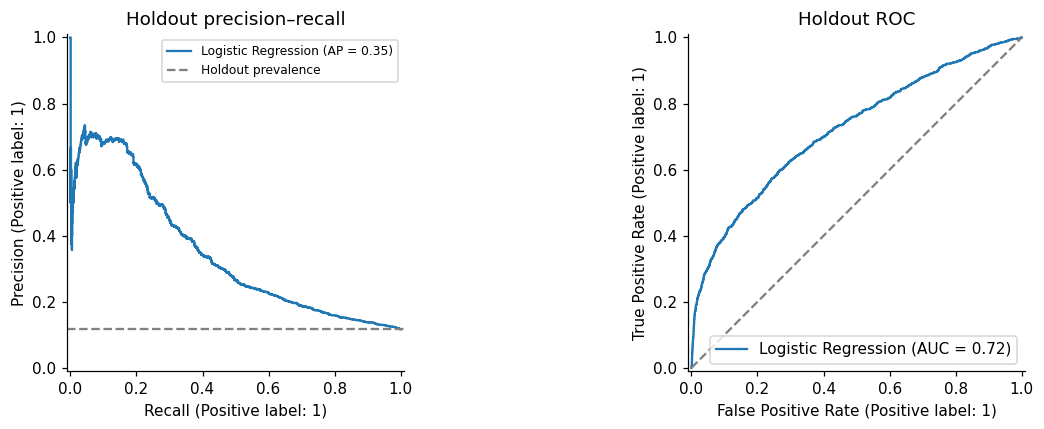

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PrecisionRecallDisplay.from_predictions(y_test, scores, ax=axes[0], name=selected_name)
axes[0].axhline(prevalence, linestyle="--", color="gray", label="Holdout prevalence")
axes[0].set_title("Holdout precision–recall")
axes[0].legend(fontsize=8)
RocCurveDisplay.from_predictions(y_test, scores, ax=axes[1], name=selected_name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Holdout ROC")
fig.tight_layout()
plt.show()

## Ranking / capacity evaluation: top 100
Rank by descending model score, with ascending source row ID as a deterministic tie-breaker.
The selected 100 receive the capacity label `Top 100`; no arbitrary probability thresholds are used.

- **Precision@100:** positive outcomes among selected records / 100.
- **Positives captured@100:** count of those historical positive outcomes.
- **Capture@100:** selected positives / all holdout positives.
- **Lift@100:** precision@100 / prevalence in this same holdout.

The random-selection reference is an expected count, not a simulated campaign result. Lift describes
concentration of observed outcomes, **not causal uplift** or extra conversions caused by contacting.

In [7]:
ranked = pd.DataFrame({
    "source_row_id": X_test.index,
    "model_score": scores,
    "actual_outcome": y_test.to_numpy(),
}).sort_values(["model_score", "source_row_id"], ascending=[False, True]).reset_index(drop=True)
top_leads = ranked.head(TOP_K).copy()
top_leads.insert(2, "priority", f"Top {TOP_K}")
positives = int(top_leads["actual_outcome"].sum())
ranking = {
    "top_k": TOP_K, "positives_captured_at_k": positives,
    "precision_at_k": positives / TOP_K,
    "capture_at_k": positives / int(y_test.sum()),
    "lift_at_k": (positives / TOP_K) / prevalence,
    "random_expected_positives_at_k": TOP_K * prevalence,
    "capacity_fraction": TOP_K / len(y_test),
    "tie_breaker": "source_row_id ascending",
}
assert len(top_leads) == TOP_K and top_leads["source_row_id"].is_unique
assert top_leads["model_score"].is_monotonic_decreasing
display(pd.Series(ranking, name="capacity_result"))
display(top_leads.head(10))

top_k                                                 100
positives_captured_at_k                                70
precision_at_k                                        0.7
capture_at_k                                     0.066163
lift_at_k                                        5.983081
random_expected_positives_at_k                  11.699657
capacity_fraction                                0.011058
tie_breaker                       source_row_id ascending
Name: capacity_result, dtype: object

,source_row_id,model_score,priority,actual_outcome
0,41917,0.840681,Top 100,1
1,41580,0.835458,Top 100,0
2,42386,0.835404,Top 100,1
3,42753,0.818055,Top 100,0
4,44800,0.817536,Top 100,1
5,43896,0.815178,Top 100,0
6,43165,0.814029,Top 100,0
7,44027,0.812516,Top 100,0
8,44664,0.812488,Top 100,1
9,43122,0.811114,Top 100,1


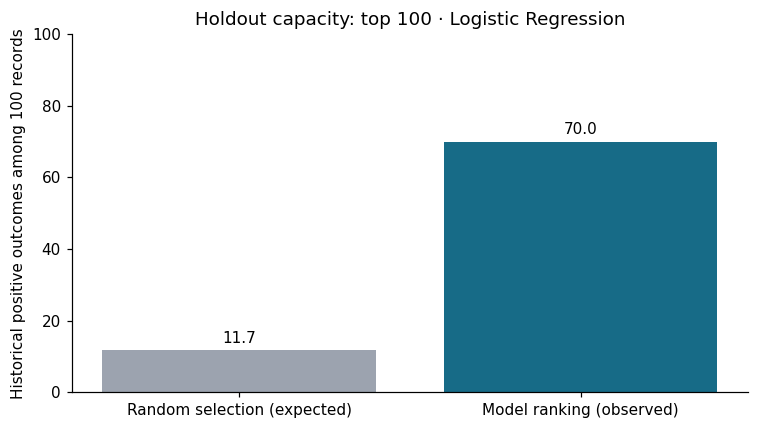

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
values = [ranking["random_expected_positives_at_k"], positives]
bars = ax.bar(["Random selection (expected)", "Model ranking (observed)"], values,
              color=["#9ca3af", "#176b87"])
ax.bar_label(bars, labels=[f"{v:.1f}" for v in values], padding=3)
ax.set_ylim(0, TOP_K)
ax.set_ylabel("Historical positive outcomes among 100 records")
ax.set_title(f"Holdout capacity: top {TOP_K} · {selected_name}")
fig.tight_layout()
plt.show()

## Reproducible demo exports
Write one top-100 CSV and one evaluation JSON from this run. The app reads both; it never fits a model or
invents KPI values. `actual_outcome` is known only retrospectively and is never a feature.
The raw source file remains unchanged. No fitted model artifact is needed for this static demonstration.

In [9]:
profile_hashes = pd.util.hash_pandas_object(X, index=False)
shared_profiles = set(profile_hashes.loc[X_train.index]) & set(profile_hashes.loc[X_test.index])
quality["duplicate_feature_rows"] = int(X.duplicated().sum())
quality["holdout_rows_with_training_feature_match"] = int(profile_hashes.loc[X_test.index].isin(shared_profiles).sum())
versions = {package: importlib.metadata.version(package) for package in
            ["pandas", "numpy", "scikit-learn", "matplotlib", "streamlit", "jupyter", "nbclient", "nbformat", "ipykernel"]}
top_leads.to_csv(ROOT / "data/top_leads.csv", index=False, float_format="%.17g")
evaluation = {
    "schema_version": 1,
    "selected_model": selected_name,
    "decision_point": "Pre-contact prioritization using client attributes and prior-campaign history",
    "score_interpretation": "Uncalibrated model score for ranking, not an individual conversion probability",
    "source_sha256": source_hash,
    "top_leads_sha256": hashlib.sha256((ROOT / "data/top_leads.csv").read_bytes()).hexdigest(),
    "features": FEATURES, "excluded_features": EXCLUDED,
    "split": {"seed": SEED, "test_fraction": 0.2, "stratified": True, "training_size": len(y_train)},
    "selection": {"folds": 3, "shuffle": True, "seed": SEED,
                  "primary_metric": "mean validation average precision",
                  "tie_breaker": "model name ascending", "results": cv_rows},
    "holdout": holdout, "ranking": ranking, "data_quality": quality,
    "environment": {"python": platform.python_version(), "packages": versions},
}
(ROOT / "data/model_evaluation.json").write_text(
    json.dumps(evaluation, indent=2, sort_keys=True, allow_nan=False) + "\n", encoding="utf-8"
)
print("Wrote data/top_leads.csv and data/model_evaluation.json")
print("Exact feature-profile matches across split:", quality["holdout_rows_with_training_feature_match"])
print("Tested environment:", evaluation["environment"])

Wrote data/top_leads.csv and data/model_evaluation.json
Exact feature-profile matches across split: 375
Tested environment: {'python': '3.14.4', 'packages': {'pandas': '3.0.2', 'numpy': '2.4.4', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.9', 'streamlit': '1.58.0', 'jupyter': '1.1.1', 'nbclient': '0.11.0', 'nbformat': '5.11.1', 'ipykernel': '7.2.0'}}


## Limitations and interpretation
- Retrospective, random-split evaluation of historical bank data; no prospective or temporal validation.
- The original holdout was inspected during the earlier project/audit. This revised procedure excludes it
  from algorithmic selection, but it is not a never-seen external dataset.
- Client profile timestamps and unique customer identifiers are unavailable; pre-contact availability is
  an explicit scenario assumption. Identical feature profiles are not proof of duplicate customers.
- Scores are uncalibrated. Results do not estimate incremental benefit from calling or establish ROI.
- Top 100 is a fixed illustrative capacity, not an optimized budget. Three CV folds and one holdout do not
  establish a universally best model. No hyperparameters were tuned against the holdout.
- Demographic and financial attributes can encode disparities; no fairness or deployment suitability
  assessment is claimed. Historical relationships may not generalize to current customers.
- AI assistance (OpenAI Codex) was used for this portfolio repair, documentation and verification.
  This statement does not establish how the original project was authored.